In [1]:
!git clone https://github.com/Mohamed-Elkady-05/AutoVision-Perception
%cd AutoVision-Perception

fatal: destination path 'AutoVision-Perception' already exists and is not an empty directory.
/content/AutoVision-Perception


## Imports & Download

In [2]:
import kagglehub
import os

print("Downloading GTSRB Dataset...")
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")

# Define the data path for the rest of the notebook
data_path = os.path.join(path, 'Train')
if not os.path.exists(data_path):
    data_path = os.path.join(path, 'train') # Fallback for lowercase

print(f"Dataset downloaded and the train folder located at: {data_path}")

Using Colab cache for faster access to the 'gtsrb-german-traffic-sign' dataset.
Dataset downloaded and the train folder located at: /kaggle/input/gtsrb-german-traffic-sign/Train


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torchvision import models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import time

try:
    from CNN_model import TrafficSignCNN
    print("Successfully imported TrafficSignCNN from CNN_model.py")
except ImportError:
    print("ERROR: Could not find CNN_model.py. Please upload it to Colab.")

# Force PyTorch to use the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Successfully imported TrafficSignCNN from CNN_model.py
Using device: cuda


## Data Preparation

In [4]:
# 1. Define Data Augmentation & Normalization for Training
train_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.RandomRotation(15),           # Augmentation: Slight rotations
    transforms.ColorJitter(brightness=0.2),  # Augmentation: Lighting variations
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))     # Standardize pixel values
])

test_transforms = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 2. Load the full dataset using the path from Cell 1
print(f"Loading images from {data_path}...")
full_dataset = datasets.ImageFolder(root=data_path, transform=train_transforms)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

val_dataset.dataset.transform = test_transforms

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"Loaded {len(train_dataset)} training images and {len(val_dataset)} validation images.")

Loading images from /kaggle/input/gtsrb-german-traffic-sign/Train...
Loaded 31367 training images and 7842 validation images.


## Training

In [5]:
# TRAINING
model = TrafficSignCNN(num_classes=43).to(device)
criterion = nn.CrossEntropyLoss()

# Improvement: L2 Regularization (weight_decay) added to the Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

epochs = 10
print(f"Starting Training for {epochs} epochs on {device}...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f}")

print("Training Complete!")

Starting Training for 10 epochs on cuda...
Epoch [1/10] - Loss: 2.1842
Epoch [2/10] - Loss: 0.7368
Epoch [3/10] - Loss: 0.2499
Epoch [4/10] - Loss: 0.1377
Epoch [5/10] - Loss: 0.0901
Epoch [6/10] - Loss: 0.0626
Epoch [7/10] - Loss: 0.0569
Epoch [8/10] - Loss: 0.0442
Epoch [9/10] - Loss: 0.0435
Epoch [10/10] - Loss: 0.0365
Training Complete!


## Evaluation

Evaluating model on validation set...
\n Validation Accuracy: 99.18%


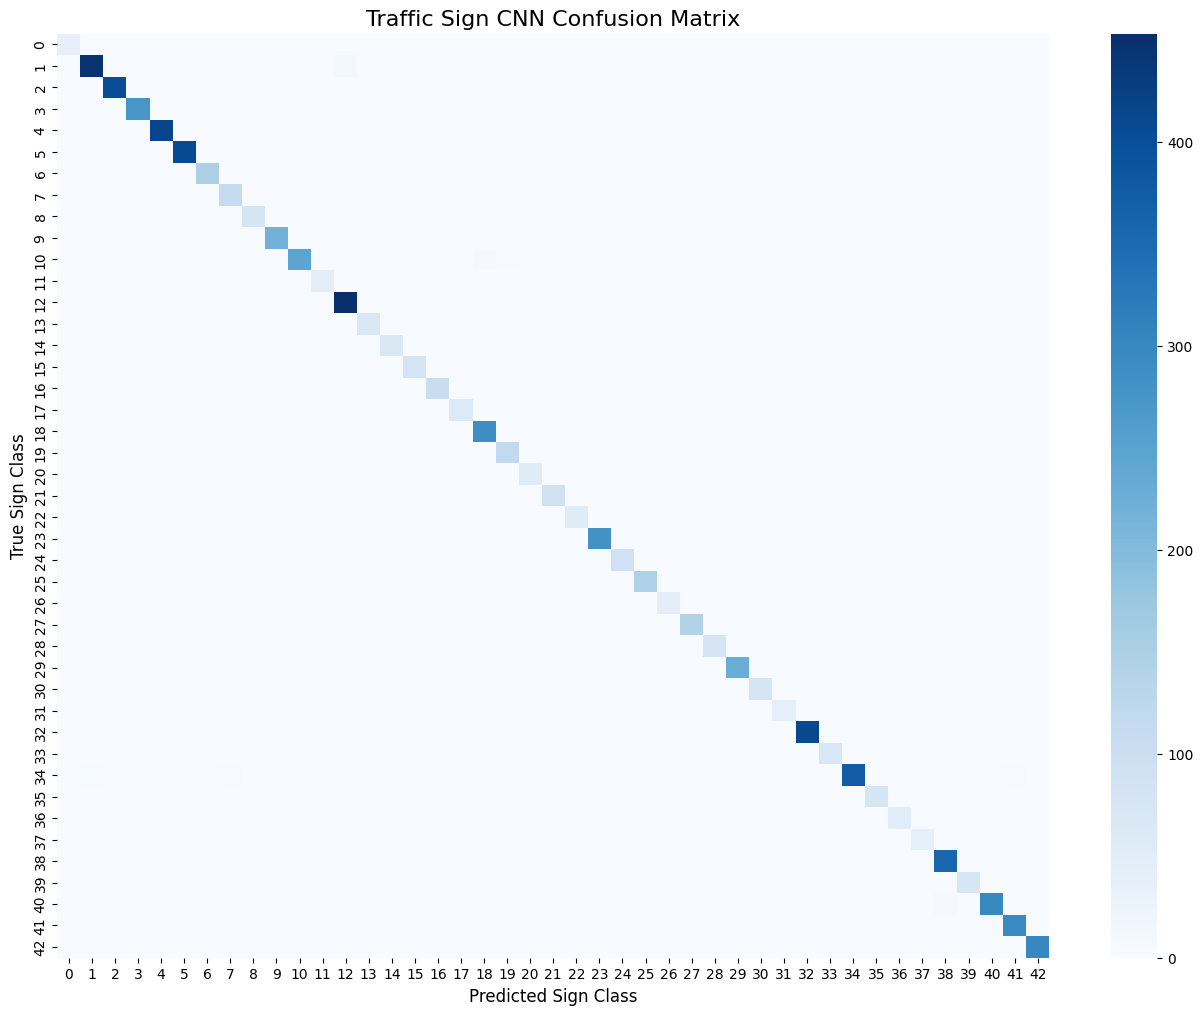

In [6]:
model.eval()
all_preds = []
all_labels = []

print("Evaluating model on validation set...")
with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"\\n Validation Accuracy: {acc * 100:.2f}%")

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(16, 12))
sns.heatmap(cm, annot=False, cmap='Blues', fmt='d')
plt.title("Traffic Sign CNN Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Sign Class", fontsize=12)
plt.ylabel("True Sign Class", fontsize=12)
plt.show()

# Transfer Learning

## helper functions

In [7]:
import gc

NUM_CLASSES = 43
WARMUP_EPOCHS = 5
FINETUNE_EPOCHS = 10

results = {
    'MobileNetV2': {'pre_acc': 0, 'final_acc': 0, 'val_loss_history': []},
    'VGG16': {'pre_acc': 0, 'final_acc': 0, 'val_loss_history': []}
}

def evaluate_model(model, dataloader):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return running_loss / total, (correct / total) * 100

def train_model(model, train_loader, val_loader, criterion, optimizer, epochs, phase_name):
    print(f"\n--- Starting {phase_name} ({epochs} Epochs) ---")
    val_loss_history = []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        # Training pass
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

        train_loss = running_loss / total
        train_acc = correct / total * 100

        # Validation pass to track history
        val_loss, val_acc = evaluate_model(model, val_loader)
        val_loss_history.append(val_loss)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_acc:.2f}% | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    return val_loss_history

def run_experiment(model_name, model, head_index, num_classes):
    print(f"\n{'='*40}\nEXPERIMENT: {model_name}\n{'='*40}")

    # Freeze Base
    for param in model.parameters():
        param.requires_grad = False

    # Replace Head
    in_features = model.classifier[head_index].in_features
    model.classifier[head_index] = nn.Linear(in_features, num_classes)
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()

    # Warm-up
    optimizer_warmup = optim.Adam(model.classifier.parameters(), lr=0.001)
    warmup_losses = train_model(model, train_loader, val_loader, criterion, optimizer_warmup, WARMUP_EPOCHS, f"{model_name} Warm-up")

    # Record Baseline Accuracy
    _, pre_acc = evaluate_model(model, val_loader)
    results[model_name]['pre_acc'] = pre_acc
    print(f">>> {model_name} Baseline Validation before Fine-tuning: {pre_acc:.2f}%")

    # Fine-tune
    for param in model.parameters():
        param.requires_grad = True
    optimizer_finetune = optim.Adam(model.parameters(), lr=1e-5)
    finetune_losses = train_model(model, train_loader, val_loader, criterion, optimizer_finetune, FINETUNE_EPOCHS, f"{model_name} Fine-Tuning")

    # Record Final Accuracy and History
    _, final_acc = evaluate_model(model, val_loader)
    results[model_name]['final_acc'] = final_acc
    results[model_name]['val_loss_history'] = warmup_losses + finetune_losses
    print(f">>> {model_name} Final Validation after Fine-tuning: {final_acc:.2f}%\n")

    # Clear Memory
    del model
    gc.collect()
    torch.cuda.empty_cache()

## training / fine-tuning

In [8]:
# Run MobileNetV2
model_mobile = models.mobilenet_v2(weights='DEFAULT')
run_experiment('MobileNetV2', model_mobile, head_index=1, num_classes=NUM_CLASSES)

# Run VGG16
model_vgg = models.vgg16(weights='DEFAULT')
run_experiment('VGG16', model_vgg, head_index=6, num_classes=NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 96.9MB/s]



EXPERIMENT: MobileNetV2

--- Starting MobileNetV2 Warm-up (5 Epochs) ---
Epoch [1/5] | Train Acc: 28.00% | Val Loss: 2.2771 | Val Acc: 39.20%
Epoch [2/5] | Train Acc: 36.66% | Val Loss: 2.1373 | Val Acc: 42.68%
Epoch [3/5] | Train Acc: 38.37% | Val Loss: 2.0626 | Val Acc: 44.10%
Epoch [4/5] | Train Acc: 39.06% | Val Loss: 2.0583 | Val Acc: 43.42%
Epoch [5/5] | Train Acc: 40.19% | Val Loss: 1.9885 | Val Acc: 45.46%
>>> MobileNetV2 Baseline Validation before Fine-tuning: 45.46%

--- Starting MobileNetV2 Fine-Tuning (10 Epochs) ---
Epoch [1/10] | Train Acc: 43.58% | Val Loss: 1.8044 | Val Acc: 48.94%
Epoch [2/10] | Train Acc: 47.32% | Val Loss: 1.6341 | Val Acc: 52.88%
Epoch [3/10] | Train Acc: 50.07% | Val Loss: 1.5480 | Val Acc: 55.15%
Epoch [4/10] | Train Acc: 52.74% | Val Loss: 1.4773 | Val Acc: 57.06%
Epoch [5/10] | Train Acc: 54.86% | Val Loss: 1.4154 | Val Acc: 58.68%
Epoch [6/10] | Train Acc: 57.29% | Val Loss: 1.3441 | Val Acc: 60.06%
Epoch [7/10] | Train Acc: 58.53% | Val Loss:

100%|██████████| 528M/528M [00:08<00:00, 67.6MB/s]



EXPERIMENT: VGG16

--- Starting VGG16 Warm-up (5 Epochs) ---
Epoch [1/5] | Train Acc: 46.80% | Val Loss: 1.1707 | Val Acc: 61.08%
Epoch [2/5] | Train Acc: 56.91% | Val Loss: 0.9740 | Val Acc: 68.52%
Epoch [3/5] | Train Acc: 59.15% | Val Loss: 0.9353 | Val Acc: 68.55%
Epoch [4/5] | Train Acc: 60.75% | Val Loss: 0.8651 | Val Acc: 71.91%
Epoch [5/5] | Train Acc: 61.49% | Val Loss: 0.8604 | Val Acc: 71.87%
>>> VGG16 Baseline Validation before Fine-tuning: 71.87%

--- Starting VGG16 Fine-Tuning (10 Epochs) ---
Epoch [1/10] | Train Acc: 73.93% | Val Loss: 0.3962 | Val Acc: 87.67%
Epoch [2/10] | Train Acc: 86.16% | Val Loss: 0.2222 | Val Acc: 93.45%
Epoch [3/10] | Train Acc: 91.91% | Val Loss: 0.1423 | Val Acc: 95.87%
Epoch [4/10] | Train Acc: 95.04% | Val Loss: 0.0993 | Val Acc: 97.12%
Epoch [5/10] | Train Acc: 96.52% | Val Loss: 0.0870 | Val Acc: 97.49%
Epoch [6/10] | Train Acc: 97.63% | Val Loss: 0.0661 | Val Acc: 98.18%
Epoch [7/10] | Train Acc: 98.27% | Val Loss: 0.0639 | Val Acc: 98.14

## Graphs

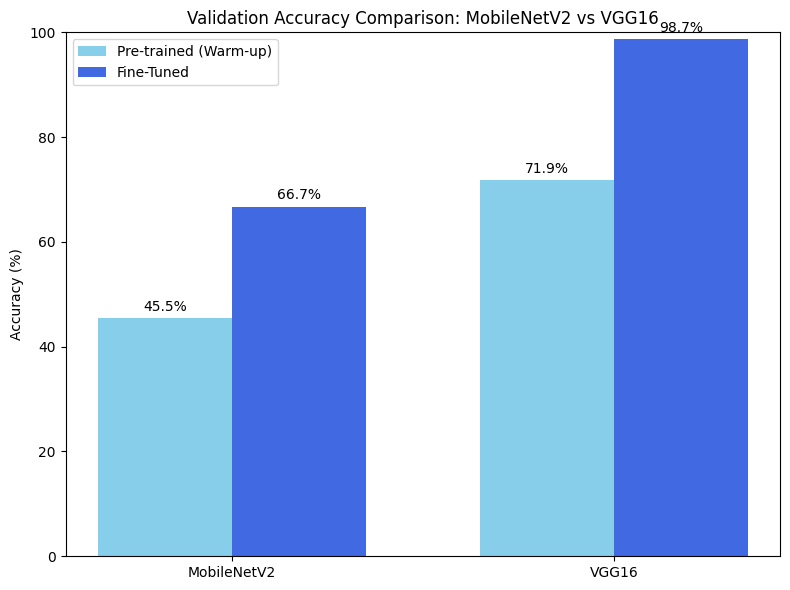

In [9]:
model_names = ['MobileNetV2', 'VGG16']
pre_accs = [results['MobileNetV2']['pre_acc'], results['VGG16']['pre_acc']]
final_accs = [results['MobileNetV2']['final_acc'], results['VGG16']['final_acc']]

x = np.arange(len(model_names))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
rects1 = ax.bar(x - width/2, pre_accs, width, label='Pre-trained (Warm-up)', color='skyblue')
rects2 = ax.bar(x + width/2, final_accs, width, label='Fine-Tuned', color='royalblue')

ax.set_ylabel('Accuracy (%)')
ax.set_title('Validation Accuracy Comparison: MobileNetV2 vs VGG16')
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 100)
ax.legend()

for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.1f}%', xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

plt.tight_layout()
plt.show()

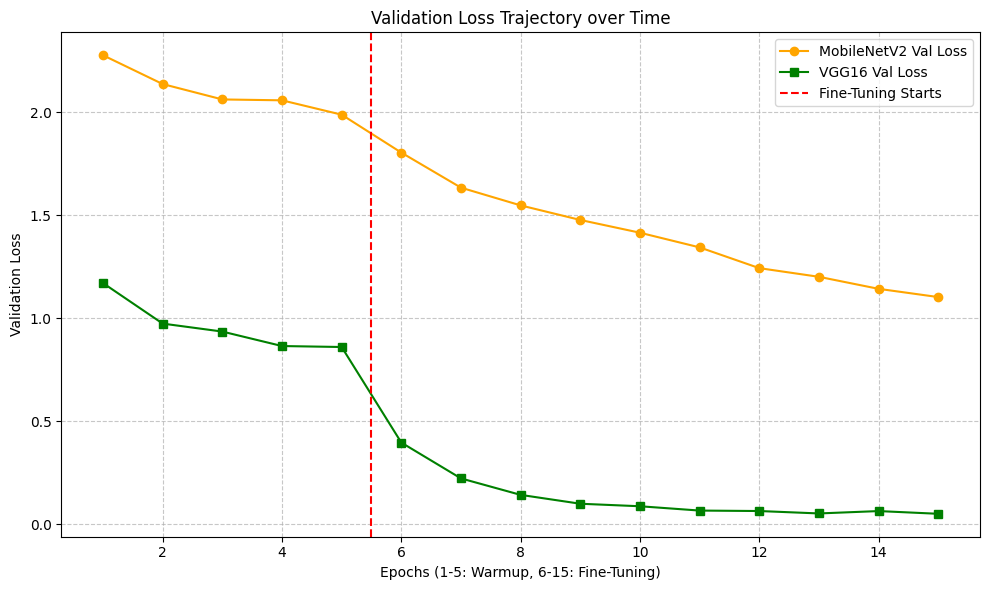

In [10]:
total_epochs = WARMUP_EPOCHS + FINETUNE_EPOCHS
epochs_axis = np.arange(1, total_epochs + 1)

mobile_loss = results['MobileNetV2']['val_loss_history']
vgg_loss = results['VGG16']['val_loss_history']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(epochs_axis, mobile_loss, marker='o', linestyle='-', color='orange', label='MobileNetV2 Val Loss')
ax.plot(epochs_axis, vgg_loss, marker='s', linestyle='-', color='green', label='VGG16 Val Loss')

ax.axvline(x=WARMUP_EPOCHS + 0.5, color='red', linestyle='--', label='Fine-Tuning Starts')

ax.set_xlabel(f'Epochs (1-{WARMUP_EPOCHS}: Warmup, {WARMUP_EPOCHS+1}-{total_epochs}: Fine-Tuning)')
ax.set_ylabel('Validation Loss')
ax.set_title('Validation Loss Trajectory over Time')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Comparison Optimizers
+ Adam
+ SGD with momentum
+ RSMProp
+ AdaGrad

In [16]:
from trainer_opt import TrainerOpt
import pandas as pd
import matplotlib.pyplot as plt

epc = 5
# all optimizers grouped
optimzers = [
    {'type': 'adam', 'lr': 0.001, 'label': 'Adam'},
    {'type': 'sgd', 'lr': 0.001, 'label': 'SGD'},
    {'type': 'rmsprop', 'lr': 0.001, 'label': 'RMSProp'},
    {'type': 'adagrad', 'lr': 0.001, 'label': 'AdaGrad'}
]

In [14]:
res = {}
criterion = nn.CrossEntropyLoss()

for opt in optimzers:
    print(f"\n>>> Starting Experiment: {opt['label']}")
    model = TrafficSignCNN(num_classes=43)
    trainer = TrainerOpt(model, optimizer=opt['type'], lr=opt['lr'], scheduler_name='plateau')

    history = {'val_loss': [], 'val_acc': [] , 'train_loss':[]}
    for epoch in range(epc):
        train_loss = trainer.train_epoch(train_loader, criterion)
        val_loss, val_acc = trainer.evaluate(val_loader, criterion)

        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['train_loss'].append(train_loss)
        print(f"Epoch {epoch+1} | Val Acc: {val_acc:.2f}% | Val Loss: {val_loss:.4f} | Train Loss: {train_loss:.4f}")

    res[opt['label']] = history


>>> Starting Experiment: Adam
Epoch 1 | Val Acc: 86.78% | Val Loss: 0.4979 | Train Loss: 1.8363
Epoch 2 | Val Acc: 96.33% | Val Loss: 0.1396 | Train Loss: 0.3282
Epoch 3 | Val Acc: 98.58% | Val Loss: 0.0491 | Train Loss: 0.1361
Epoch 4 | Val Acc: 98.56% | Val Loss: 0.0538 | Train Loss: 0.0821
Epoch 5 | Val Acc: 99.25% | Val Loss: 0.0275 | Train Loss: 0.0556

>>> Starting Experiment: SGD
Epoch 1 | Val Acc: 7.36% | Val Loss: 3.4597 | Train Loss: 3.5951
Epoch 2 | Val Acc: 9.55% | Val Loss: 3.3588 | Train Loss: 3.4190
Epoch 3 | Val Acc: 14.49% | Val Loss: 3.2588 | Train Loss: 3.3402
Epoch 4 | Val Acc: 22.79% | Val Loss: 2.8469 | Train Loss: 3.1163
Epoch 5 | Val Acc: 35.83% | Val Loss: 2.2345 | Train Loss: 2.6410

>>> Starting Experiment: RMSProp
Epoch 1 | Val Acc: 63.99% | Val Loss: 0.9863 | Train Loss: 1.9730
Epoch 2 | Val Acc: 86.07% | Val Loss: 0.4185 | Train Loss: 0.4641
Epoch 3 | Val Acc: 98.18% | Val Loss: 0.0626 | Train Loss: 0.1662
Epoch 4 | Val Acc: 98.53% | Val Loss: 0.0549 | Tr

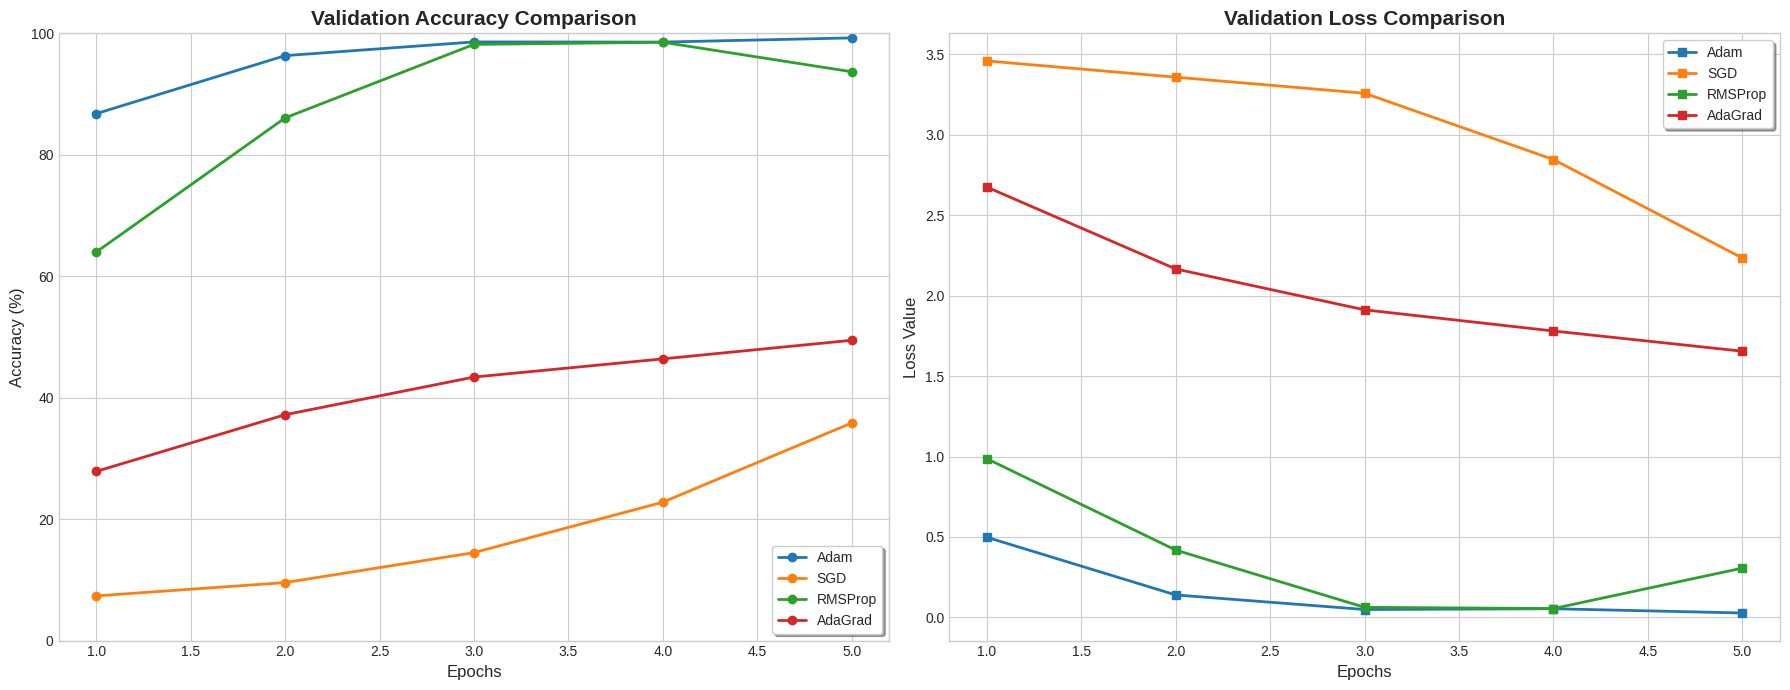


📊 Final Comparison Summary:
Optimizer Final Accuracy Min Loss
     Adam         99.25%   0.0275
      SGD         35.83%   2.2345
  RMSProp         93.68%   0.0549
  AdaGrad         49.45%   1.6550


In [15]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

for i, (label, data) in enumerate(res.items()):
    epochs_range = range(1, len(data['val_acc']) + 1)

    ax1.plot(epochs_range, data['val_acc'], label=label, marker='o', color=colors[i], linewidth=2)

    ax2.plot(epochs_range, data['val_loss'], label=label, marker='s', color=colors[i], linewidth=2)

ax1.set_title('Validation Accuracy Comparison', fontsize=15, fontweight='bold')
ax1.set_xlabel('Epochs', fontsize=12)
ax1.set_ylabel('Accuracy (%)', fontsize=12)
ax1.legend(frameon=True, shadow=True)
ax1.set_ylim(0, 100)

ax2.set_title('Validation Loss Comparison', fontsize=15, fontweight='bold')
ax2.set_xlabel('Epochs', fontsize=12)
ax2.set_ylabel('Loss Value', fontsize=12)
ax2.legend(frameon=True, shadow=True)

plt.tight_layout()
plt.show()

final_results = []
for label, data in res.items():
    final_results.append({
        'Optimizer': label,
        'Final Accuracy': f"{data['val_acc'][-1]:.2f}%",
        'Min Loss': f"{min(data['val_loss']):.4f}"
    })

df_results = pd.DataFrame(final_results)
print("\n📊 Final Comparison Summary:")
print(df_results.to_string(index=False))